In [96]:
# Обновление окружения:
using Pkg
Pkg.update
# Установка пакетов:
using Pkg
for p in ["CSV", "DataFrames", "RDatasets", "FileIO"]
Pkg.add(p)
end
using CSV, DataFrames, DelimitedFiles

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [97]:
# Считывание данных и их запись в структуру:
P = CSV.File("programminglanguages.csv") |> DataFrame

Row,year,language
,Int64,String31
1,1951,Regional Assembly Language
2,1952,Autocode
3,1954,IPL
4,1955,FLOW-MATIC
5,1957,FORTRAN
6,1957,COMTRAN
7,1958,LISP
8,1958,ALGOL 58
9,1959,FACT


In [98]:
# Функция определения по названию языка программирования года его создания:
function language_created_year(P,language::String)
    loc = findfirst(P[:,2].==language)
    return P[loc,1]
end

language_created_year (generic function with 1 method)

In [99]:
# Пример вызова функции и определение даты создания языка Python:
language_created_year(P,"Python")

1991

In [100]:
# Пример вызова функции и определение даты создания языка Julia:
language_created_year(P,"Julia")

2012

In [101]:
language_created_year(P,"julia")

LoadError: MethodError: no method matching getindex(::DataFrame, ::Nothing, ::Int64)
The function `getindex` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  getindex(::DataFrame, [91m::Colon[39m, ::Union{AbstractString, Signed, Symbol, Unsigned})
[0m[90m   @[39m [36mDataFrames[39m [90m~/.julia/packages/DataFrames/b4w9K/src/dataframe/[39m[90m[4mdataframe.jl:542[24m[39m
[0m  getindex(::DataFrame, [91m::typeof(!)[39m, ::Union{Signed, Unsigned})
[0m[90m   @[39m [36mDataFrames[39m [90m~/.julia/packages/DataFrames/b4w9K/src/dataframe/[39m[90m[4mdataframe.jl:548[24m[39m
[0m  getindex(::DataFrame, [91m::InvertedIndex[39m, ::Union{AbstractString, Signed, Symbol, Unsigned})
[0m[90m   @[39m [36mDataFrames[39m [90m~/.julia/packages/DataFrames/b4w9K/src/dataframe/[39m[90m[4mdataframe.jl:538[24m[39m
[0m  ...


In [102]:
# Функция определения по названию языка программирования
# года его создания (без учёта регистра):
function language_created_year_v2(P,language::String)
    loc = findfirst(lowercase.(P[:,2]).==lowercase.(language))
    return P[loc,1]
end

language_created_year_v2 (generic function with 1 method)

In [103]:
# Пример вызова функции и определение даты создания языка julia:
language_created_year_v2(P,"julia")

2012

In [104]:
# Построчное считывание данных с указанием разделителя:
Tx = readdlm("programminglanguages.csv", ',')

74×2 Matrix{Any}:
     "year"  "language"
 1951        "Regional Assembly Language"
 1952        "Autocode"
 1954        "IPL"
 1955        "FLOW-MATIC"
 1957        "FORTRAN"
 1957        "COMTRAN"
 1958        "LISP"
 1958        "ALGOL 58"
 1959        "FACT"
 1959        "COBOL"
 1959        "RPG"
 1962        "APL"
    ⋮        
 2003        "Scala"
 2005        "F#"
 2006        "PowerShell"
 2007        "Clojure"
 2009        "Go"
 2010        "Rust"
 2011        "Dart"
 2011        "Kotlin"
 2011        "Red"
 2011        "Elixir"
 2012        "Julia"
 2014        "Swift"

In [105]:
# Запись данных в CSV-файл:
CSV.write("programming_languages_data2.csv", P)

"programming_languages_data2.csv"

In [106]:
# Пример записи данных в текстовый файл с разделителем ',':
writedlm("programming_languages_data.txt", Tx, ',')
# Пример записи данных в текстовый файл с разделителем '-':
writedlm("programming_languages_data2.txt", Tx, '-')

In [107]:
# Построчное считывание данных с указанием разделителя:
P_new_delim = readdlm("programming_languages_data2.txt", '-')

74×2 Matrix{Any}:
     "year"  "language"
 1951        "Regional Assembly Language"
 1952        "Autocode"
 1954        "IPL"
 1955        "FLOW-MATIC"
 1957        "FORTRAN"
 1957        "COMTRAN"
 1958        "LISP"
 1958        "ALGOL 58"
 1959        "FACT"
 1959        "COBOL"
 1959        "RPG"
 1962        "APL"
    ⋮        
 2003        "Scala"
 2005        "F#"
 2006        "PowerShell"
 2007        "Clojure"
 2009        "Go"
 2010        "Rust"
 2011        "Dart"
 2011        "Kotlin"
 2011        "Red"
 2011        "Elixir"
 2012        "Julia"
 2014        "Swift"

In [108]:
# Инициализация словаря:
dict = Dict{Integer,Vector{String}}()

Dict{Integer, Vector{String}}()

In [109]:
# Инициализация словаря:
dict2 = Dict()

Dict{Any, Any}()

In [110]:
# Заполнение словаря данными:
for i = 1:size(P,1)
    year,lang = P[i,:]
    if year in keys(dict)
        dict[year] = push!(dict[year],lang)
    else
        dict[year] = [lang]
    end
end

In [111]:
# Пример определения в словаре языков программирования, созданных в 2003 году
dict[2003]

2-element Vector{String}:
 "Groovy"
 "Scala"

In [112]:
# Подгружаем пакет DataFrames:
using DataFrames
# Задаём переменную со структурой DataFrame:
df = DataFrame(year = P[:,1], language = P[:,2])

Row,year,language
,Int64,String31
1,1951,Regional Assembly Language
2,1952,Autocode
3,1954,IPL
4,1955,FLOW-MATIC
5,1957,FORTRAN
6,1957,COMTRAN
7,1958,LISP
8,1958,ALGOL 58
9,1959,FACT


In [113]:
# Вывод всех значения столбца year:
df[!,:year]

73-element Vector{Int64}:
 1951
 1952
 1954
 1955
 1957
 1957
 1958
 1958
 1959
 1959
 1959
 1962
 1962
    ⋮
 2003
 2005
 2006
 2007
 2009
 2010
 2011
 2011
 2011
 2011
 2012
 2014

In [114]:
# Получение статистических сведений о фрейме:
describe(df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,year,1982.99,1951,1986.0,2014,0,Int64
2,language,,ALGOL 58,,dBase III,0,String31


In [115]:
# Подгружаем пакет RDatasets:
using RDatasets
# Задаём структуру данных в виде набора данных:
iris = dataset("datasets", "iris")

Row,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
,Float64,Float64,Float64,Float64,Cat…
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa
7,4.6,3.4,1.4,0.3,setosa
8,5.0,3.4,1.5,0.2,setosa
9,4.4,2.9,1.4,0.2,setosa


In [116]:
# Определения типа переменной:
typeof(iris)

DataFrame

In [117]:
describe(iris)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,SepalLength,5.84333,4.3,5.8,7.9,0,Float64
2,SepalWidth,3.05733,2.0,3.0,4.4,0,Float64
3,PetalLength,3.758,1.0,4.35,6.9,0,Float64
4,PetalWidth,1.19933,0.1,1.3,2.5,0,Float64
5,Species,,setosa,,virginica,0,"CategoricalValue{String, UInt8}"


In [118]:
# Отсутствующий тип:
a = missing
typeof(a)

Missing

In [119]:
# Пример операции с переменной отсутствующего типа:
a + 1

missing

In [120]:
# Определение перечня продуктов:
foods = ["apple", "cucumber", "tomato", "banana"]
# Определение калорий:
calories = [missing,47,22,105]

4-element Vector{Union{Missing, Int64}}:
    missing
  47
  22
 105

In [121]:
# Определение типа переменной:
typeof(calories)

Vector{Union{Missing, Int64}} (alias for Array{Union{Missing, Int64}, 1})

In [122]:
# Подключаем пакет Statistics:
using Statistics
# Определение среднего значения:
mean(calories)

missing

In [123]:
# Определение среднего значения без значений с отсутствующим типом:
mean(skipmissing(calories))

58.0

In [124]:
# Задание сведений о ценах:
prices = [0.85,1.6,0.8,0.6]
# Формирование данных о калориях:
dataframe_calories = DataFrame(item=foods,calories=calories)
# Формирование данных о ценах:
dataframe_prices = DataFrame(item=foods,price=prices)
# Объединение данных о калориях и ценах:
DF = innerjoin(dataframe_calories,dataframe_prices,on=:item)

Row,item,calories,price
,String,Int64?,Float64
1,apple,missing,0.85
2,cucumber,47,1.6
3,tomato,22,0.8
4,banana,105,0.6


In [125]:
# Подключаем пакет FileIO:
using FileIO

In [126]:
# Подключаем пакет ImageIO:
import Pkg
Pkg.add("ImageIO")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


┌ Warning: Output swatches are reduced due to the large size (180×280).
│ Load the ImageShow package for large images.
└ @ Colors ~/.julia/packages/Colors/VFEJ1/src/display.jl:159


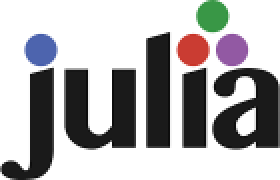

In [127]:
# Загрузка изображения:
X1 = load("julialogo.png")

In [128]:
# Определение типа и размера данных:
@show typeof(X1);
@show size(X1);

typeof(X1) = IndirectArrays.IndirectArray{RGB{FixedPointNumbers.N0f8}, 2, UInt8, Matrix{UInt8}, OffsetArrays.OffsetVector{RGB{FixedPointNumbers.N0f8}, Vector{RGB{FixedPointNumbers.N0f8}}}}
size(X1) = (180, 280)


In [129]:
# Загрузка пакетов:
import Pkg
Pkg.add("DataFrames")
Pkg.add("Statistics")
using DataFrames
using CSV
import Pkg
Pkg.add("Plots")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [130]:
# Загрузка данных:
houses = CSV.File("houses.csv") |> DataFrame

Row,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
,String,String15,Int64,String3,Int64,Int64,Int64,String15,String31,Int64,Float64,Float64
1,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.6319,-121.435
2,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.4789,-121.431
3,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.6183,-121.444
4,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.6168,-121.439
5,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.5195,-121.436
6,5828 PEPPERMILL CT,SACRAMENTO,95841,CA,3,1,1122,Condo,Wed May 21 00:00:00 EDT 2008,89921,38.6626,-121.328
7,6048 OGDEN NASH WAY,SACRAMENTO,95842,CA,3,2,1104,Residential,Wed May 21 00:00:00 EDT 2008,90895,38.6817,-121.352
8,2561 19TH AVE,SACRAMENTO,95820,CA,3,1,1177,Residential,Wed May 21 00:00:00 EDT 2008,91002,38.5351,-121.481
9,11150 TRINITY RIVER DR Unit 114,RANCHO CORDOVA,95670,CA,2,2,941,Condo,Wed May 21 00:00:00 EDT 2008,94905,38.6212,-121.271


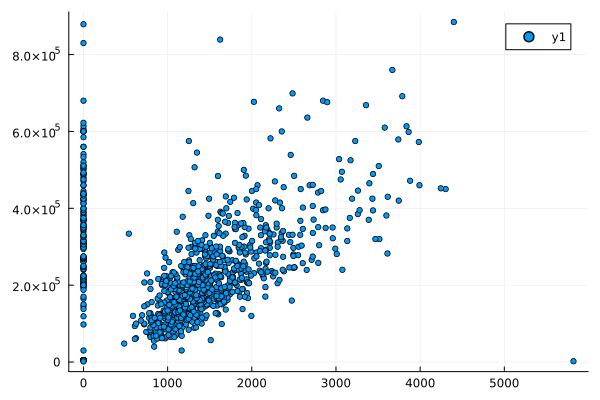

In [131]:
# Построение графика:
using Plots
plot(size=(500,500),leg=false)
x = houses[!,:sq__ft]
y = houses[!,:price]
scatter(x,y,markersize=3)

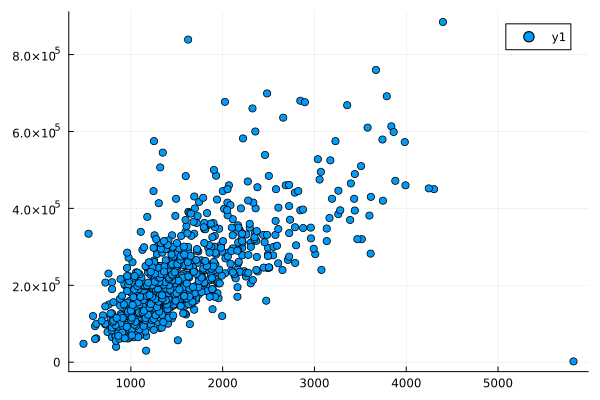

In [132]:
# Фильтрация данных по заданному условию:
filter_houses = houses[houses[!,:sq__ft].>0,:]
# Построение графика:
x = filter_houses[!,:sq__ft]
y = filter_houses[!,:price]
scatter(x,y)

In [133]:
# Подключение пакета Statistics:
using Statistics
# Определение средней цены для определённого типа домов:
combine(groupby(filter_houses, :type), :price => mean)

Row,type,price_mean
,String15,Float64
1,Residential,2.34802e5
2,Condo,1.34213e5
3,Multi-Family,2.24535e5


   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


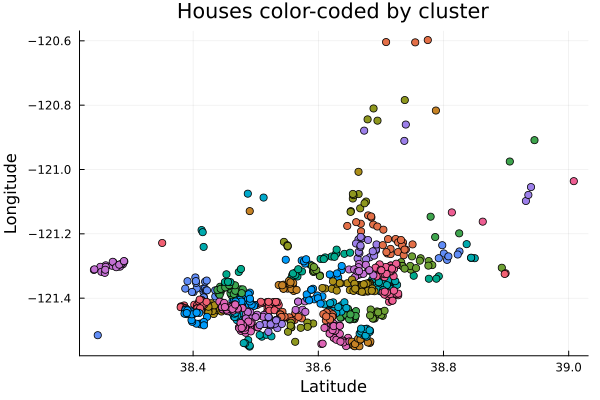

In [134]:
import Pkg
Pkg.add("Clustering")
using Clustering
# Добавление данных :latitude и :longitude в новый фрейм:
X = filter_houses[:, [:latitude,:longitude]]

#Преобразование DataFrame в матрицу
X = Matrix{Float64}(X)'
k = length(unique(filter_houses[:, :zip]))

# Определение кластеров k-среднего
C = kmeans(X, k)

# Формирование DataFrame с результатами кластеризации
df = DataFrame(
    cluster = C.assignments,
    city = filter_houses[:, :city],
    latitude = filter_houses[:, :latitude],
    longitude = filter_houses[:, :longitude],
    zip = filter_houses[:, :zip]
)

# Построение графиков кластеров
clusters_figure = plot(legend=false)
for i in 1:k
    clustered_houses = df[df[:, :cluster] .== i, :]
    xvals = clustered_houses[:, :latitude]
    yvals = clustered_houses[:, :longitude]
    scatter!(clusters_figure, xvals, yvals, markersize=4)
end
xlabel!("Latitude")
ylabel!("Longitude")
title!("Houses color-coded by cluster")
display(clusters_figure)

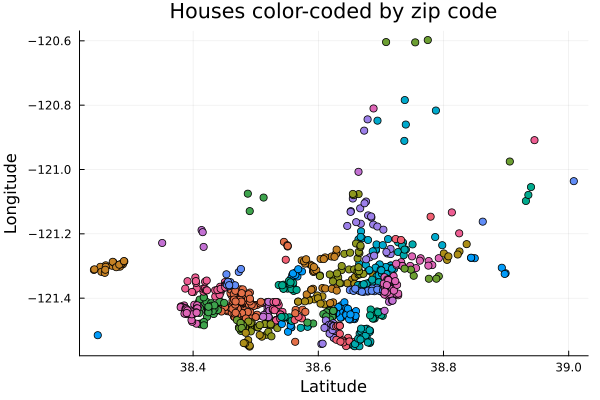

In [135]:
unique_zips = unique(filter_houses[!,:zip])
zips_figure = plot(legend = false)
for uzip in unique_zips
    subs = filter_houses[filter_houses[!,:zip].==uzip,:]
    x = subs[!,:latitude]
    y = subs[!,:longitude]
    scatter!(zips_figure,x,y)
end
xlabel!("Latitude")
ylabel!("Longitude")
title!("Houses color-coded by zip code")
display(zips_figure)

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


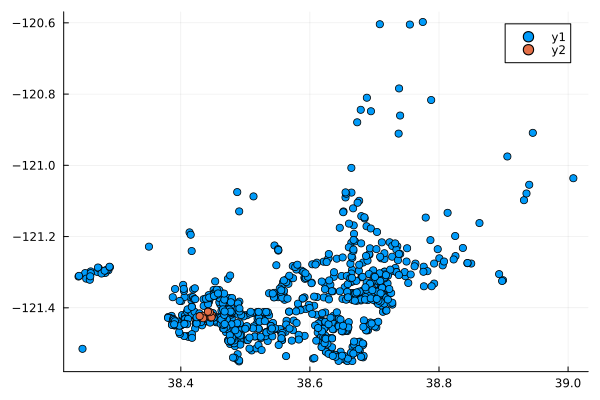

In [136]:
import Pkg
Pkg.add("NearestNeighbors")
using NearestNeighbors

knearest = 10
id = 70
point = X[:,id]

# Поиск ближайших соседей:
kdtree = KDTree(X)
idxs, dists = knn(kdtree, point, knearest, true)

# Все объекты недвижимости:
x = filter_houses[!,:latitude];
y = filter_houses[!,:longitude];
scatter(x,y)
# Соседи:
x = filter_houses[idxs,:latitude];
y = filter_houses[idxs,:longitude];
scatter!(x,y)

In [137]:
# Фильтрация по районам соседних домов:
cities = filter_houses[idxs,:city]

10-element PooledArrays.PooledVector{String15, UInt32, Vector{UInt32}}:
 "SACRAMENTO"
 "ELK GROVE"
 "SACRAMENTO"
 "SACRAMENTO"
 "SACRAMENTO"
 "SACRAMENTO"
 "ELK GROVE"
 "ELK GROVE"
 "ELK GROVE"
 "ELK GROVE"

In [138]:
Pkg.add("MultivariateStats")
using MultivariateStats  
using LinearAlgebra      
using Plots              

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


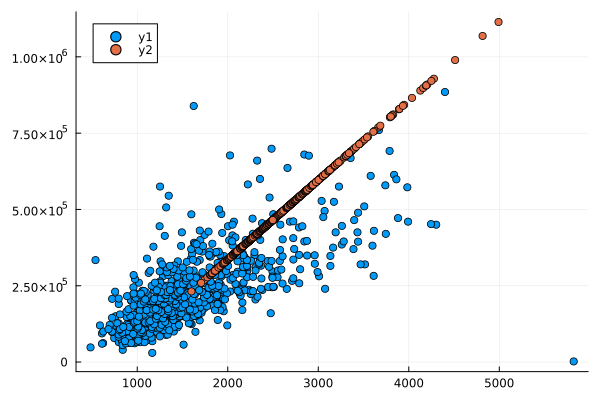

In [139]:
# Фрейм с указанием площади и цены недвижимости:
F = filter_houses[!, [:sq__ft,:price]]
y = filter_houses[!, :price]
F = Matrix(F)'
y = y'
# Приведение типов данных к распределению для PCA:
M = fit(PCA, F)
# Выделение значений главных компонентв отдельную переменную
Xr = reconstruct(M, y)
# Построение графика с выделением главных компонент
scatter(F[1,:], F[2,:])
scatter!(Xr[1,:],Xr[2,:])

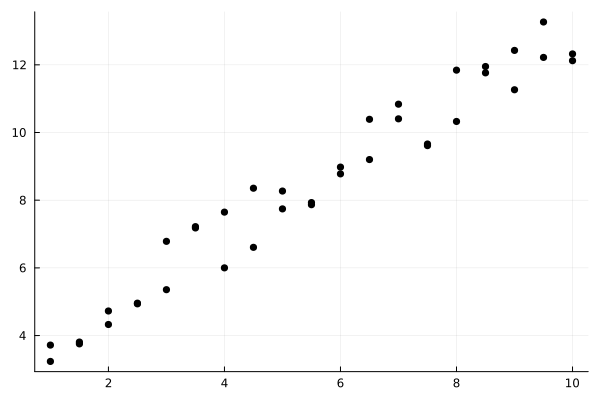

In [140]:
xvals = repeat(1:0.5:10,inner=2)
yvals = 3 .+ xvals + 2*rand(length(xvals)) .- 1
scatter(xvals,yvals,color=:black,leg=false)

In [141]:
function find_best_fit(xvals,yvals)
    meanx = mean(xvals)
    meany = mean(yvals)
    stdx = std(xvals)
    stdy = std(yvals)
    r = cor(xvals,yvals)
    a = r*stdy/stdx
    b = meany - a*meanx
    return a,b
end

find_best_fit (generic function with 1 method)

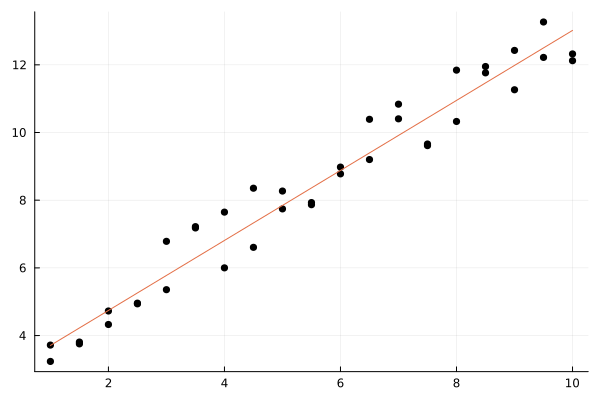

In [142]:
a,b = find_best_fit(xvals,yvals)
ynew = a * xvals .+ b
plot!(xvals,ynew)

In [143]:
xvals = 1:100000;
xvals = repeat(xvals,inner=3);
yvals = 3 .+ xvals + 2*rand(length(xvals)) .- 1;
@show size(xvals)
@show size(yvals)

size(xvals) = (300000,)
size(yvals) = (300000,)


(300000,)

In [144]:
@time a,b = find_best_fit(xvals,yvals)

  0.020382 seconds (4.38 k allocations: 230.047 KiB, 85.43% compilation time)


(1.0000000396709656, 3.000216230582737)

In [145]:
import Pkg
Pkg.add("PyCall")
Pkg.add("Conda")
using PyCall
using Conda

py"""
import numpy
def find_best_fit_python(xvals,yvals):
    meanx = numpy.mean(xvals)
    meany = numpy.mean(yvals)
    stdx = numpy.std(xvals)
    stdy = numpy.std(yvals)
    r = numpy.corrcoef(xvals,yvals)[0][1]
    a = r*stdy/stdx
    b = meany - a*meanx
    return a,b
"""
xpy = PyObject(xvals)
ypy = PyObject(yvals)
@time a,b = py"find_best_fit_python"(xpy,ypy)

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


  0.009900 seconds (100 allocations: 3.641 KiB)


(1.0000000396709676, 3.0002162304808735)

In [146]:
import Pkg
Pkg.add("BenchmarkTools")
using BenchmarkTools
@btime a,b = py"find_best_fit_python"(xvals,yvals)
@btime a,b = find_best_fit(xvals,yvals)

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


  4.738 ms (34 allocations: 960 bytes)
  1.019 ms (1 allocation: 32 bytes)


(1.0000000396709656, 3.000216230582737)

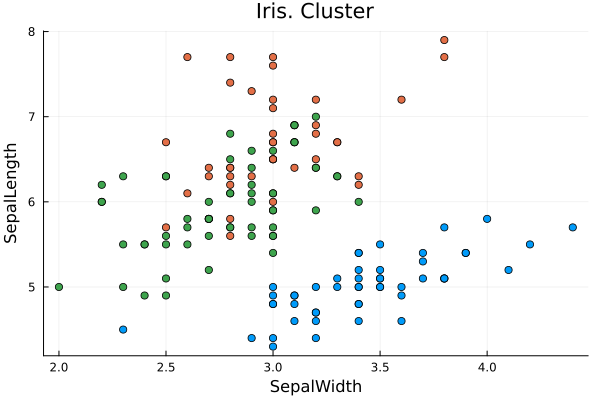

In [160]:
using RDatasets, Clustering, Plots
iris = dataset("datasets", "iris")

iris = dataset("datasets", "iris")
iris_spec = Dict("setosa"=>1, "versicolor"=>2, "virginica"=>3)
iris[!, :5] = [iris_spec[item] for item in iris[!, :5]]

X = Matrix(iris)'
k = length(unique(iris[!, :5]))
C = kmeans(X, k)
df = DataFrame(cluster = C.assignments, SepalLength = iris[!, :SepalLength],
    SepalWidth = iris[!, :SepalWidth], PetalLength = iris[!, :PetalLength],
    PetalWidth = iris[!, :PetalWidth], Species = iris[!, :Species]
)

clusters_figure = plot(legend = false)
for i = 1:k
    clustered_houses = df[df[!, :cluster].== i, :]
    xvals = clustered_houses[!, :SepalWidth]
    yvals = clustered_houses[!, :SepalLength]
    scatter!(clusters_figure, xvals, yvals, markersize = 4)
end
xlabel!("SepalWidth")
ylabel!("SepalLength")
title!("Iris. Cluster")
display(clusters_figure)

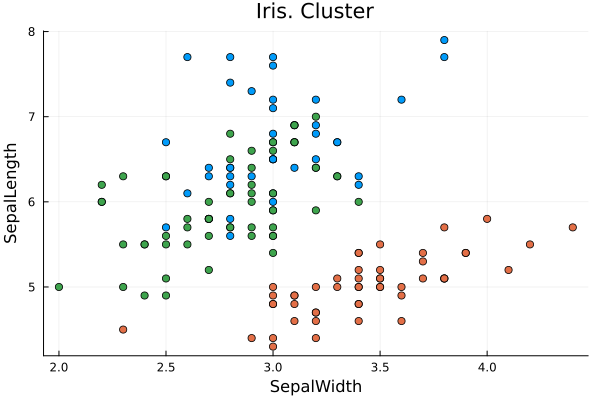

In [151]:
clusters_figure = plot(legend = false)
for i = 1:k
    clustered_houses = df[df[!, :cluster].== i, :]
    xvals = clustered_houses[!, :SepalWidth]
    yvals = clustered_houses[!, :SepalLength]
    scatter!(clusters_figure, xvals, yvals, markersize = 4)
end
xlabel!("SepalWidth")
ylabel!("SepalLength")
title!("Iris. Cluster")
display(clusters_figure)

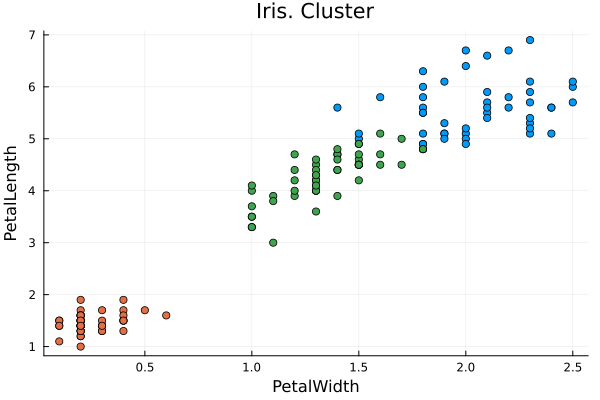

In [152]:
clusters_figure = plot(legend=false)
for i = 1:k
    clustered_houses = df[df[!, :cluster].== i, :]
    xvals = clustered_houses[!, :PetalWidth]
    yvals = clustered_houses[!, :PetalLength]
    scatter!(clusters_figure, xvals, yvals, markersize = 4)
end
xlabel!("PetalWidth")
ylabel!("PetalLength")
title!("Iris. Cluster")
display(clusters_figure)

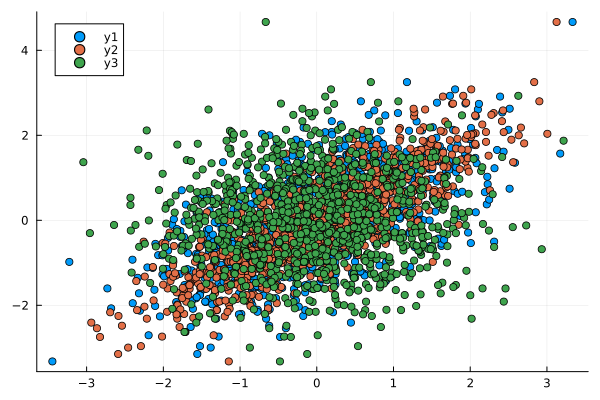

In [153]:
X = randn(1000, 3)
a0 = rand(3)
y = X * a0 + 0.1 * randn(1000)
scatter(X, y, vals = (1, 2, 3))

In [154]:
X2 = hcat(ones(1000), X)
beta = (X2' * X2) \ (X2' * y)

4-element Vector{Float64}:
 -0.00286621504429712
  0.6341176413533149
  0.8532612112348272
  0.03153307554101222

In [155]:
using MultivariateStats
beta_mvs = llsq(X, y)

4-element Vector{Float64}:
  0.6341176413533149
  0.8532612112348268
  0.031533075541012215
 -0.0028662150442970947

In [156]:
Pkg.add("GLM")
using GLM
df = DataFrame(hcat(X, y), :auto)
rename!(df, ["x1", "x2", "x3", "y"])
model = lm(@formula(y ~ x1 + x2 + x3), df)
coef(model)

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


4-element Vector{Float64}:
 -0.0028662150442971034
  0.6341176413533149
  0.853261211234827
  0.031533075541012215

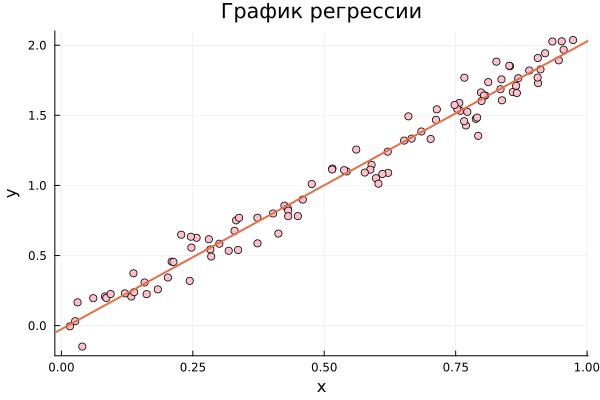

In [157]:
X = rand(100)
y = 2X + 0.1 * randn(100)
a, b = find_best_fit(X, y)
scatter(X, y, c = "pink", title = "График регрессии", xlabel='x', ylabel='y', leg=false)
Plots.abline!(a, b, lw=2)

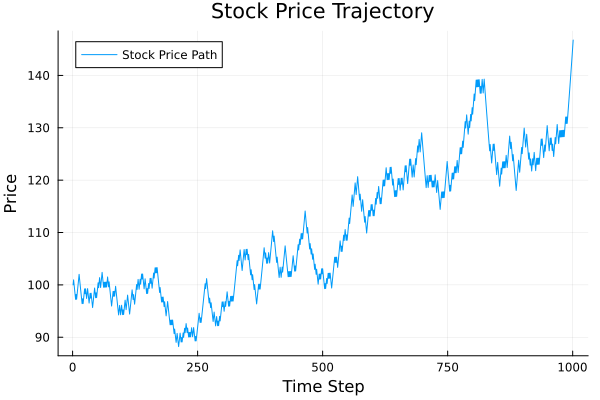

In [158]:
S = 100.0
T = 1.0
n = 1000
sigma = 0.3
r = 0.08
h = T / n

u = exp(r * h + sigma * sqrt(h))
d = exp(r * h - sigma * sqrt(h))
p = (exp(r * h) - d) / (u - d)

function create_path(S, r, sigma, T, n)
    path = []
    S_ = S
    push!(path, S)
    for i in 1:n
        if rand() < p
            S_ *= u
        else
            S_ *= d
        end
        push!(path, S_)
    end
    return path
end

path = create_path(S, r, sigma, T, n)
plot(path, label="Stock Price Path", xlabel="Time Step", ylabel="Price", title="Stock Price Trajectory")

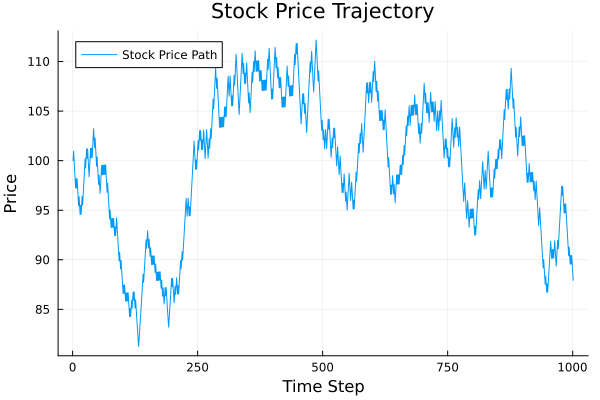

In [159]:
path = create_path(S, r, sigma, T, n)
plot(path, label="Stock Price Path", xlabel="Time Step", ylabel="Price", title="Stock Price Trajectory")


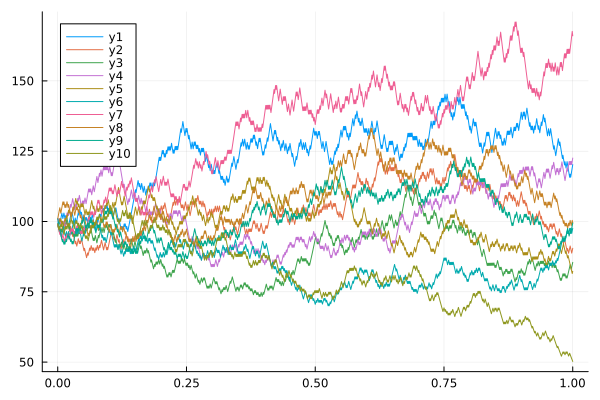

In [90]:
function createPath(S::Float64, r::Float64, sigma::Float64, T::Float64, n::Int64)
    Y = Vector()
    X = collect(0:T/n:1)
    u = exp(r * h + sigma * sqrt(h))
    d = exp(r * h - sigma * sqrt(h))
    p = (exp(r * h) - d) / (u - d)
    for i = 0:n
        prob = rand()
        if prob < p
            S *= u
        else
            S *= d
        end
        push!(Y, S)
    end
    return(X, Y)
end

p = plot()
for i = 1:10
    plot!(p, createPath(S, r, sigma, T, n))
end
p

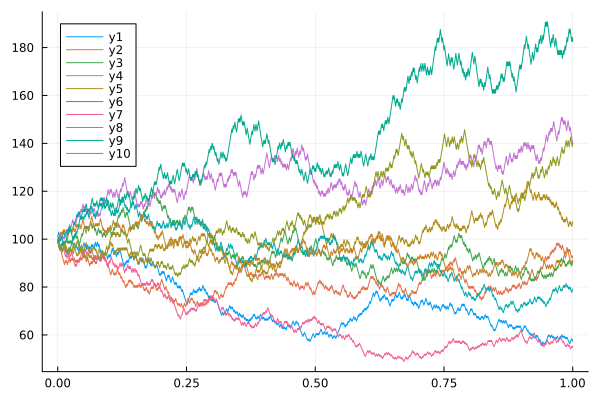

In [91]:
p = plot()
for i = 1:10
    plot!(p, createPath(S, r, sigma, T, n))
end
p

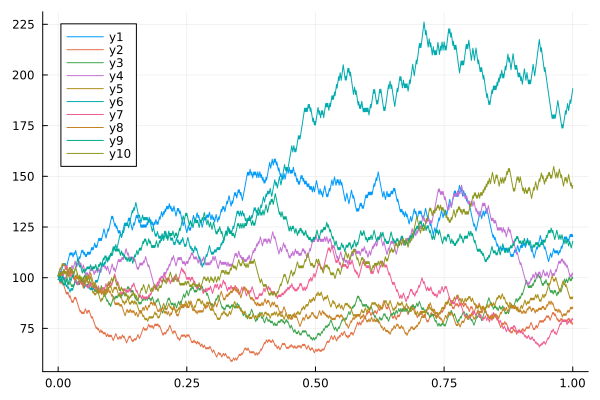

In [92]:
function createPath_(S::Float64, r::Float64, sigma::Float64, T::Float64, n::Int64)
    Y = Vector()
    X = collect(0:T/n:1)
    u = exp(r * h + sigma * sqrt(h))
    d = exp(r * h - sigma * sqrt(h))
    p = (exp(r * h) - d) / (u - d)
    Threads.@threads for i = 0:n
        prob = rand()
        if prob < p
            S *= u
        else
            S *= d
        end
        push!(Y, S)
    end
    return(X, Y)
end

p = plot()
for i = 1:10
    plot!(p, createPath_(S, r, sigma, T, n))
end
p

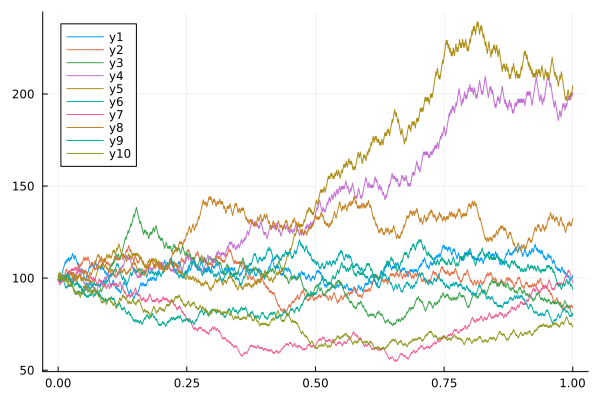

In [93]:
p = plot()
for i = 1:10
    plot!(p, createPath_(S, r, sigma, T, n))
end
p